# Comparing Strategies for the Composition of Grover Oracles from Domain-agnostic Building Blocks

## Setup

In [1]:
import json
import numpy as np
import os
from pprint import pprint
from statistics import mean, stdev
from typing import List, Dict

In [2]:
%pip install matplotlib
import matplotlib.pyplot as plt

You should consider upgrading via the '/Users/christophstein/Documents/jku/gospl/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## Util functions

In [3]:
def printb(text: str) -> None:
    print("\033[1m" + text + "\033[0m")

In [4]:
def load_json(path: str) -> Dict:
    with open(path, "r") as json_file:
        return json.load(json_file)

## Load Data

In [5]:
def load_experiments(results_dir: str = "results") -> List:
    experiments = []

    for file_name in os.listdir(results_dir):
        if not file_name.endswith(".json"):
            continue

        experiment = load_json(f"{results_dir}/{file_name}")
        experiments.append(experiment)

    return experiments

In [6]:
def filter_experiments(experiments: List, params: Dict={}, prefix=None) -> List:
    filtered_experiments = []

    for experiment in experiments:
        if prefix is not None and not experiment["meta"]["experiment_prefix"].startswith(prefix):
            continue

        all_params_match = True
        for key in params:
            if experiment["params"][key] != params[key]:
                all_params_match = False
                break

        if all_params_match:
            filtered_experiments.append(experiment)

    return filtered_experiments

In [7]:
def sort_experiments(experiments: List, key: str):
    experiments.sort(key=lambda experiment: experiment["params"][key])

## Data Extraction

In [8]:
def get_signal_qubit_counts(experiments: List, sorted=True) -> List[int]:

    signal_qubit_counts = []
    add_none = False 

    for experiment in experiments:

        if experiment["params"]["buffer_qubits"] is not None:
            signal_qubit_counts.append(experiment["params"]["buffer_qubits"])
        else:
            add_none = True

    signal_qubit_counts = list(set(signal_qubit_counts))

    if sorted:
        signal_qubit_counts.sort()

    if add_none:
        signal_qubit_counts.append(None)

    return signal_qubit_counts

In [9]:
def get_variable_counts(experiments: List, sorted=True) -> List[int]:
    variable_counts = []

    for experiment in experiments:
        variable_counts.append(experiment["params"]["variable_count"])

    variable_counts = list(set(variable_counts))

    if sorted:
        variable_counts.sort()

    return variable_counts

In [10]:
def get_edge_counts(experiments: List, sorted=True) -> List[int]:
    edge_counts = []

    for experiment in experiments:
        edge_counts.append(experiment["params"]["edge_count"])

    edge_counts = list(set(edge_counts))

    if sorted:
        edge_counts.sort()

    return edge_counts

In [11]:
def get_node_counts(experiments: List, sorted=True) -> List[int]:
    node_counts = []

    for experiment in experiments:
        node_counts.append(experiment["params"]["node_count"])

    node_counts = list(set(node_counts))

    if sorted:
        node_counts.sort()

    return node_counts

In [12]:
def get_probabilities(experiments: List, constraint_violations: int = 0) -> List[float]:
    probabilities = []

    for experiment in experiments:

        for result in experiment["results"]:
            if result["constraint_violations"] == constraint_violations:
                probabilities.append(result["mean_prob"])
                break 

    return probabilities

In [13]:
def get_solution_counts(experiments: List, constraint_violations: int = 0) -> List[float]:
    solution_counts = []

    for experiment in experiments:

        for result in experiment["results"]:
            if result["constraint_violations"] == constraint_violations:
                solution_counts.append(result["state_count"])
                break 

    return solution_counts

In [14]:
def get_gate_counts(experiments: List) -> List[float]:
    gate_counts = []

    for experiment in experiments:
        gate_counts.append(experiment["encoding"]["gates"])

    return gate_counts

In [15]:
def get_circuit_depths(experiments: List) -> List[float]:
    gate_counts = []

    for experiment in experiments:
        gate_counts.append(experiment["encoding"]["depth"])

    return gate_counts

In [16]:
def get_constraint_counts(experiments: List) -> List[float]:
    constraint_counts = []

    for experiment in experiments:
        constraint_counts.append(experiment["encoding"]["constraints"])

    return constraint_counts

In [17]:
def compute_sudoku_search_space_sizes(experiments: List) -> List[int]:
    search_space_sizes = []

    for experiment in experiments:
        search_space_sizes.append(experiment["params"]["variable_count"] ** 4)

    search_space_sizes = list(set(search_space_sizes))
    search_space_sizes.sort()
    return search_space_sizes


In [18]:
def compute_graph_coloring_search_space_sizes(experiments: List) -> List[int]:
    search_space_sizes = []

    for experiment in experiments:
        search_space_sizes.append(experiment["params"]["node_count"] ** experiment["params"]["color_count"])

    search_space_sizes = list(set(search_space_sizes))
    search_space_sizes.sort()
    return search_space_sizes


In [19]:
def get_oracle_depths(experiments: List) -> List[int]:
    oracle_depths = []

    for experiment in experiments:
        # -1 for hadamard layer
        # -7 for diffusor
        oracle_depth = experiment["encoding"]["depth"] - 7 - 1
        oracle_depths.append(oracle_depth)

    return oracle_depths


In [20]:
def get_oracle_gate_counts(experiments: List) -> List[int]:
    gate_counts = []

    for experiment in experiments:

        variable_qubits = experiment["encoding"]["variables"] * 2 # assumes 2 qubits per variable

        gate_count = experiment["encoding"]["gates"] - variable_qubits - (4 * variable_qubits + 3)
        gate_counts.append(gate_count)

    return gate_counts


## Visualization Functions

In [21]:
def plot_probability_per_signal_qubit_count(experiments: List, target_path: str = None, classical_probability: float = None):
    signal_qubit_counts = get_signal_qubit_counts(experiments)

    x = []
    mean_probabilities = []
    std_probabilities = []

    for signal_qubit_count in signal_qubit_counts:
        rel_experiments = filter_experiments(experiments, params={
            "buffer_qubits": signal_qubit_count
        })

        if signal_qubit_count is None:
            # Depending on how the problem instance is initialized,
            # constraint counts and therefore buffer qubit counts
            # might deviate slightly.
            x.append(max(get_constraint_counts(rel_experiments)))
        else:
            x.append(signal_qubit_count)

        solution_counts = get_solution_counts(rel_experiments, constraint_violations=0)
        probabilities = get_probabilities(
            rel_experiments, constraint_violations=0)
        
        probabilities = [
            probability * solution_count for probability, solution_count in zip(probabilities, solution_counts)
        ]

        mean_probabilities.append(mean(probabilities))
        std_probabilities.append(stdev(probabilities))

    ax = plt.subplot()

    ax.plot(x, mean_probabilities, label="QC probability") # TODO: Find better labels.

    lower_bounds = [value - std for value,
                    std in zip(mean_probabilities, std_probabilities)]
    upper_bounds = [value + std for value,
                    std in zip(mean_probabilities, std_probabilities)]

    ax.fill_between(
        x, lower_bounds, upper_bounds, alpha=0.2
    )

    if classical_probability is not None:
        classical_probability = max(get_solution_counts(experiments, constraint_violations=0)) * classical_probability
        ax.plot(x, [classical_probability for _ in x], label="classical probability", linestyle="dashed", linewidth=1)

    ax.set_xlabel("signal qubits")
    ax.set_ylabel("probability")
    ax.set_xticks(x)

    ax.set_ylim(0)

    print("Probabilities:", mean_probabilities)
    print("Signal qubit counts:", x)

    plt.grid()
    plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [22]:
def plot_oracle_gates_per_signal_qubit_count(experiments: List, target_path: str = None):
    signal_qubit_counts = get_signal_qubit_counts(experiments)

    x = []
    mean_gate_count = []
    std_gate_count = []

    for signal_qubit_count in signal_qubit_counts:
        rel_experiments = filter_experiments(experiments, params={
            "buffer_qubits": signal_qubit_count
        })

        if signal_qubit_count is None:
            # Depending on how the problem instance is initialized,
            # constraint counts and therefore buffer qubit counts
            # might deviate slightly.
            x.append(max(get_constraint_counts(rel_experiments)))
        else:
            x.append(signal_qubit_count)

        gate_counts = get_oracle_gate_counts(rel_experiments)

        mean_gate_count.append(mean(gate_counts))
        std_gate_count.append(stdev(gate_counts))

    ax = plt.subplot()

    ax.plot(x, mean_gate_count)

    lower_bounds = [value - std for value, std in zip(mean_gate_count, std_gate_count)]
    upper_bounds = [value + std for value, std in zip(mean_gate_count, std_gate_count)]
    
    ax.fill_between(
        x, lower_bounds, upper_bounds, alpha=0.2
    )

    ax.set_xlabel("signal qubits")
    ax.set_ylabel("gate count")
    ax.set_xticks(x)

    ax.set_ylim(0)

    print("Gate counts:", mean_gate_count)
    print("Signal qubit counts:", x)

    plt.grid()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [23]:
def plot_oracle_depth_per_signal_qubit_count(experiments: List, target_path: str = None):
    signal_qubit_counts = get_signal_qubit_counts(experiments)

    x = []
    mean_oracle_depths = []
    std_oracle_depths = []

    for signal_qubit_count in signal_qubit_counts:
        rel_experiments = filter_experiments(experiments, params={
            "buffer_qubits": signal_qubit_count
        })

        if signal_qubit_count is None:
            # Depending on how the problem instance is initialized,
            # constraint counts and therefore buffer qubit counts
            # might deviate slightly.
            x.append(max(get_constraint_counts(rel_experiments)))
        else:
            x.append(signal_qubit_count)

        oracle_depths = get_oracle_depths(rel_experiments)

        mean_oracle_depths.append(mean(oracle_depths))
        std_oracle_depths.append(stdev(oracle_depths))

    ax = plt.subplot()

    ax.plot(x, mean_oracle_depths)

    lower_bounds = [value - std for value, std in zip(mean_oracle_depths, std_oracle_depths)]
    upper_bounds = [value + std for value, std in zip(mean_oracle_depths, std_oracle_depths)]
    
    ax.fill_between(
        x, lower_bounds, upper_bounds, alpha=0.2
    )

    ax.set_xlabel("signal qubits")
    ax.set_ylabel("oracle depth")
    ax.set_xticks(x)

    ax.set_ylim(0)

    print("Oracle depths:", mean_oracle_depths)
    print("Signal qubit counts:", x)

    plt.grid()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [24]:
def plot_violations_per_signal_qubit_count(experiments: List, target_path: str = None):

    signal_qubit_counts = get_signal_qubit_counts(experiments)

    x = []

    probabilities_of_violation_count = [
        [],
        [],
        [],
        []
    ]
    probabilities_of_rest = []

    for signal_qubit_count in signal_qubit_counts:
        rel_experiments = filter_experiments(experiments, params={
            "buffer_qubits": signal_qubit_count
        })

        if signal_qubit_count is None:
            # Depending on how the problem instance is initialized,
            # constraint counts and therefore buffer qubit counts
            # might deviate slightly.
            x.append(max(get_constraint_counts(rel_experiments)))
        else:
            x.append(signal_qubit_count)

        violation_counts = {}

        for experiment in rel_experiments:
            for result in experiment["results"]:
                violations = result["constraint_violations"]
                state_count = result["state_count"]
                probability = result["mean_prob"]

                probability_mass = state_count * probability

                if violations not in violation_counts:
                    violation_counts[violations] = [probability_mass]
                else:
                    violation_counts[violations].append(probability_mass)

        used_probabilities = 0

        for i in range(len(probabilities_of_violation_count)):
            if i in violation_counts:
                mean_probability = mean(violation_counts[i])
                probabilities_of_violation_count[i].append(mean_probability)
                used_probabilities += mean_probability
            else:
                probabilities_of_violation_count[i].append(0)


        probabilities_of_rest.append(1 - used_probabilities)


    ax = plt.subplot()

    y = probabilities_of_violation_count + [probabilities_of_rest]
    y = list(reversed(y))
    y = np.vstack(y)
    
    labels = [
        f"{i} constraint violations" for i in range(len(probabilities_of_violation_count))
    ] + ["rest"]
    labels = list(reversed(labels))

    ax.stackplot(x, y, labels=labels)

    ax.set_xlabel("signal qubits")
    ax.set_ylabel("probability masses per constraint violation")
    ax.set_xticks(x)

    ax.set_ylim(0)

    plt.legend()
    plt.grid()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

## Sudoku Results

In [25]:
experiments = load_experiments()

sudoku_experiments = filter_experiments(experiments, prefix="sudoku")
print(f"Number of sudoku experiments: {len(sudoku_experiments)}")
print(f"Search space sizes: {compute_sudoku_search_space_sizes(sudoku_experiments)}")

Number of sudoku experiments: 419
Search space sizes: [16, 256, 625]


### Probabilities per Signal Qubit Count


Sudoku results with 2 unspecified cells

Probability of measuring a correct solution over signal qubit count:
Probabilities: [0.12007833333333333, 0.2763333333333333, 0.3556203333333333, 0.47300166666666665]
Signal qubit counts: [1, 3, 5, 7]


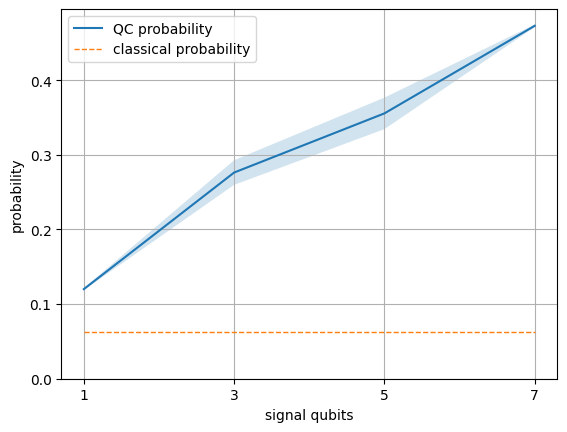

Violations per signal qubit count:


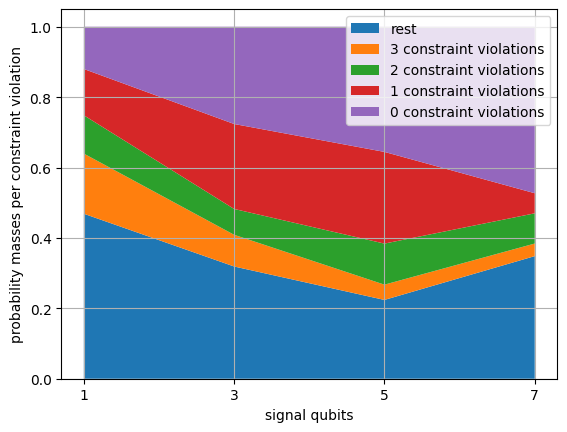


Sudoku results with 4 unspecified cells

Probability of measuring a correct solution over signal qubit count:
Probabilities: [0.007868, 0.020572666666666666, 0.025167, 0.03083733333333333, 0.034592]
Signal qubit counts: [1, 3, 5, 10, 17]


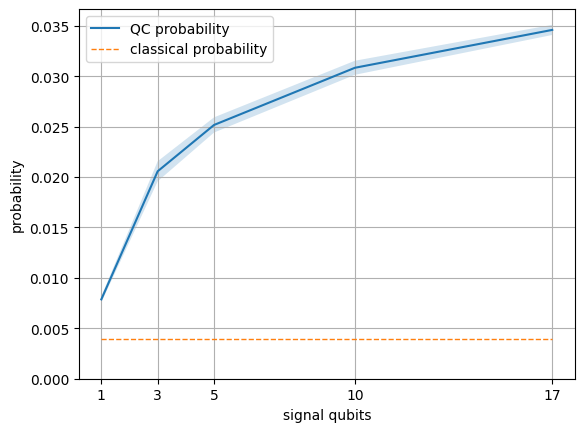

Violations per signal qubit count:


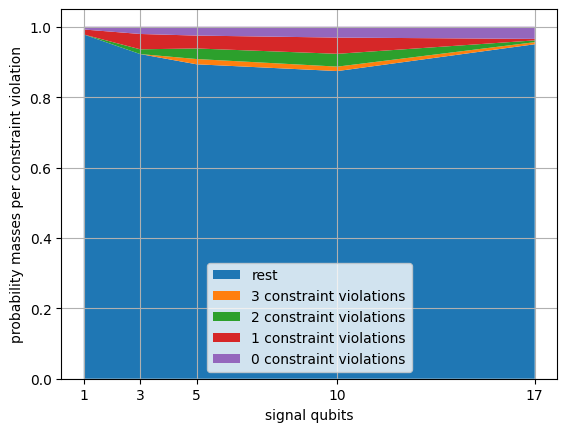


Sudoku results with 5 unspecified cells

Probability of measuring a correct solution over signal qubit count:
Probabilities: [0.0019986206896551724, 0.005386333333333333, 0.006683333333333334, 0.008209, 0.008716551724137931]
Signal qubit counts: [1, 3, 5, 10, 21]


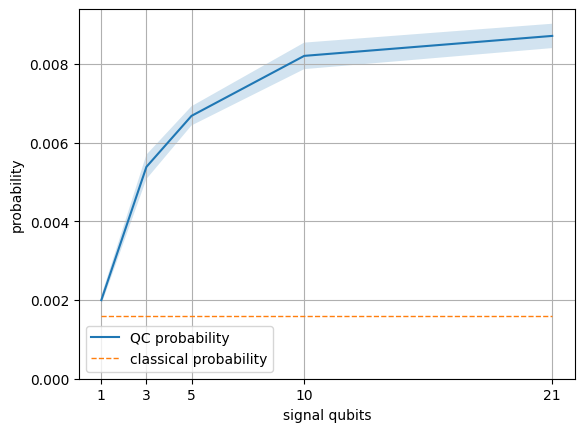

Violations per signal qubit count:


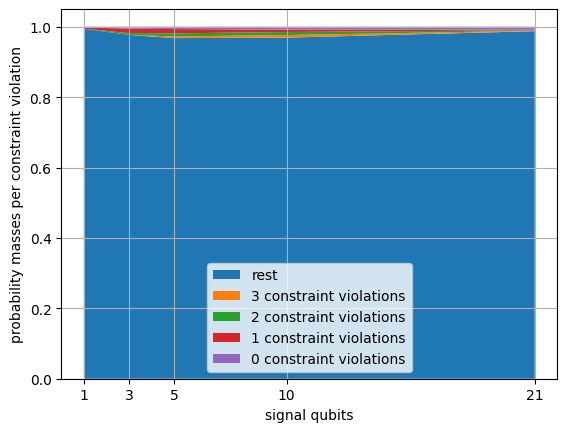

<Figure size 640x480 with 0 Axes>

In [26]:
variable_counts = get_variable_counts(sudoku_experiments)

for variable_count in variable_counts:
    rel_sudoku_experiments = filter_experiments(
        sudoku_experiments, params={
            "variable_count": variable_count
        }
    )

    printb(f"\nSudoku results with {variable_count} unspecified cells\n")

    print("Probability of measuring a correct solution over signal qubit count:")
    classical_probability = 1 / compute_sudoku_search_space_sizes(rel_sudoku_experiments)[0]
    plot_probability_per_signal_qubit_count(
        rel_sudoku_experiments, target_path=f"figures/sudoku_{variable_count}v_probabilities.png", 
        classical_probability=classical_probability
    )

    print("Violations per signal qubit count:")
    plot_violations_per_signal_qubit_count(rel_sudoku_experiments)

### Circuit Depth per Signal Qubit Count


Sudoku results with 2 unspecified cells

Oracle depth over signal qubit count:
Oracle depths: [37.96666666666667, 34.166666666666664, 29.8, 28.533333333333335]
Signal qubit counts: [1, 3, 5, 7]


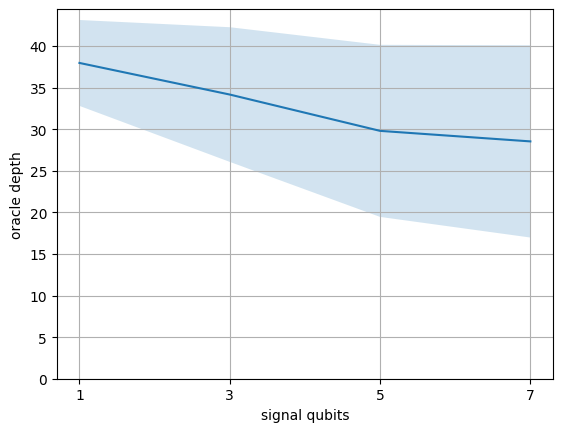

Oracle gates over signal qubit count:
Gate counts: [69.9, 65.9, 65.33333333333333, 64.33333333333333]
Signal qubit counts: [1, 3, 5, 7]


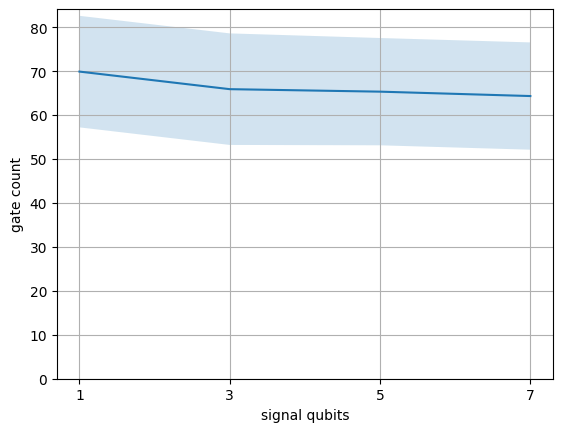


Sudoku results with 4 unspecified cells

Oracle depth over signal qubit count:
Oracle depths: [89.06666666666666, 74.03333333333333, 68.96666666666667, 64.86666666666666, 62.2]
Signal qubit counts: [1, 3, 5, 10, 17]


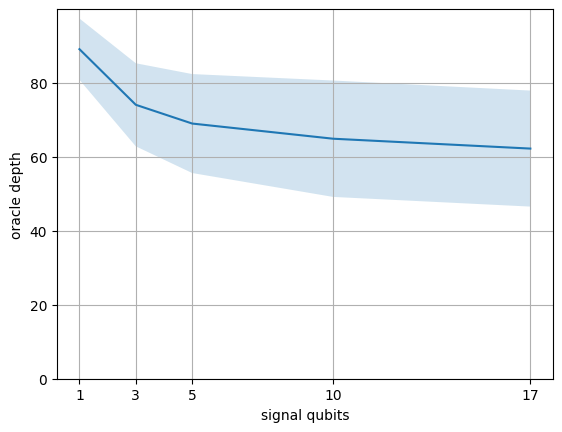

Oracle gates over signal qubit count:
Gate counts: [177.1, 167.6, 165.6, 164.4, 163.4]
Signal qubit counts: [1, 3, 5, 10, 17]


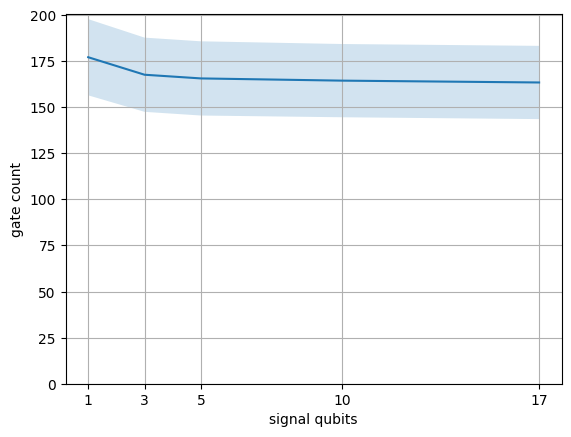


Sudoku results with 5 unspecified cells

Oracle depth over signal qubit count:
Oracle depths: [118.9, 94.7, 87.5, 81.23333333333333, 80.6896551724138]
Signal qubit counts: [1, 3, 5, 10, 21]


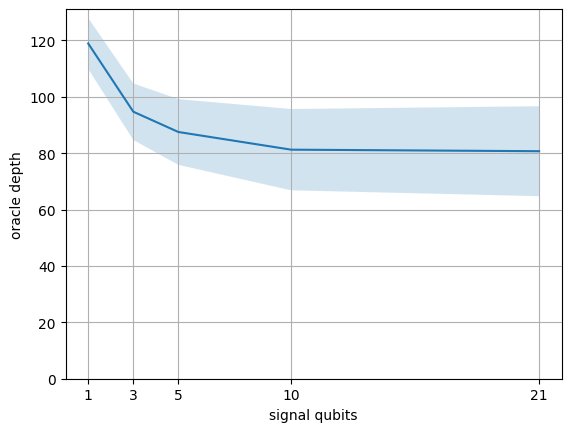

Oracle gates over signal qubit count:
Gate counts: [242.3, 229.86666666666667, 227.2, 225.2, 222.0344827586207]
Signal qubit counts: [1, 3, 5, 10, 21]


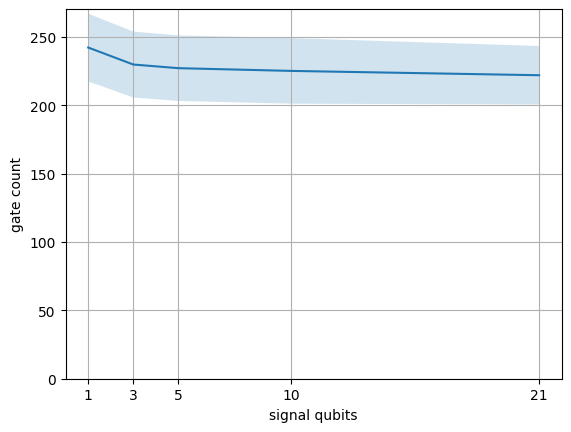

<Figure size 640x480 with 0 Axes>

In [27]:
variable_counts = get_variable_counts(sudoku_experiments)

for variable_count in variable_counts:
    rel_sudoku_experiments = filter_experiments(
        sudoku_experiments, params={
            "variable_count": variable_count
        }
    )

    printb(f"\nSudoku results with {variable_count} unspecified cells\n")

    print("Oracle depth over signal qubit count:")
    plot_oracle_depth_per_signal_qubit_count(
        rel_sudoku_experiments, target_path=f"figures/sudoku_{variable_count}v_circuit_depths.png"
    )

    print("Oracle gates over signal qubit count:")
    plot_oracle_gates_per_signal_qubit_count(
        rel_sudoku_experiments
    )

## Graph Coloring Results

In [28]:
graph_coloring_experiments = filter_experiments(experiments, prefix="graph_coloring")

print(f"\nNumber of graph coloring experiments: {len(graph_coloring_experiments)}")
print(f"Search space sizes: {compute_graph_coloring_search_space_sizes(graph_coloring_experiments)}")


Number of graph coloring experiments: 360
Search space sizes: [64, 625]


### Probabilities per Signal Qubit Count


Graph results with 4 nodes and 3 edges

Probability of measuring a correct solution over signal qubit count:
Probabilities: [0.13721533333333333, 0.275736, 0.3834823333333333, 0.6164826666666666]
Signal qubit counts: [1, 3, 5, 7]


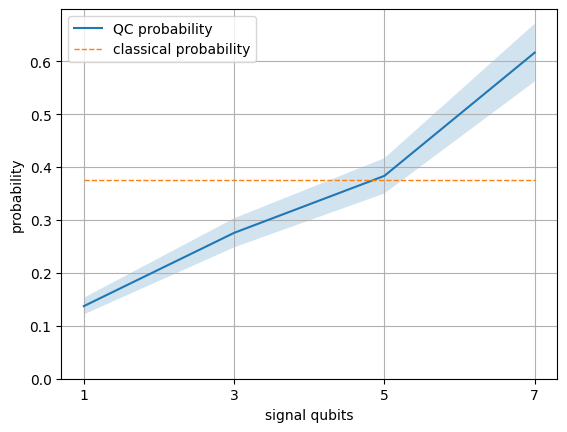

Violations per signal qubit count:


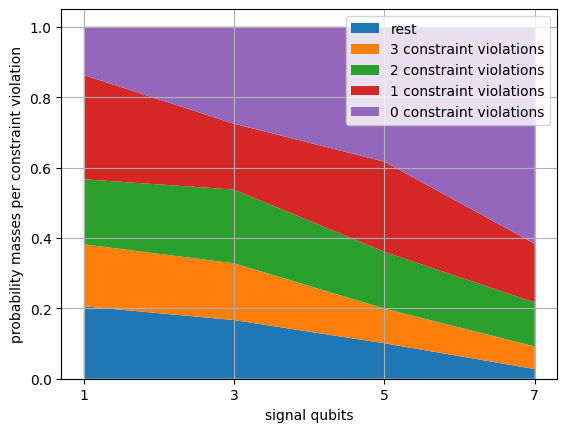


Graph results with 4 nodes and 5 edges

Probability of measuring a correct solution over signal qubit count:
Probabilities: [0.03948566666666667, 0.09282433333333333, 0.114919, 0.19837966666666668]
Signal qubit counts: [1, 3, 5, 9]


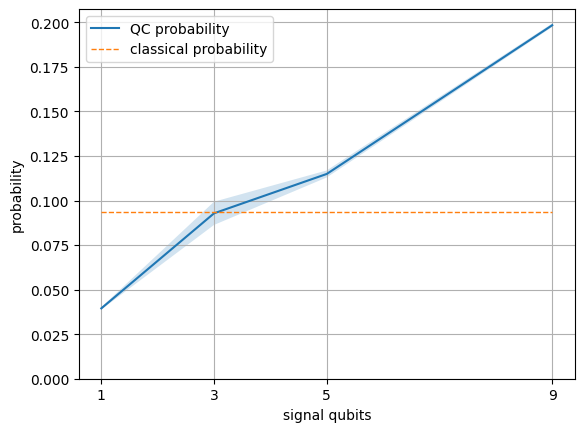

Violations per signal qubit count:


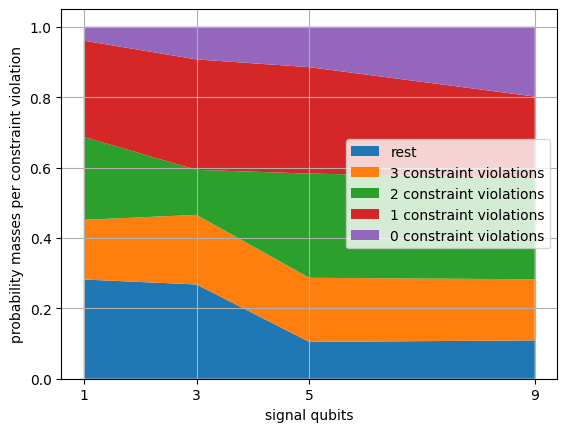


Graph results with 5 nodes and 8 edges

Probability of measuring a correct solution over signal qubit count:
Probabilities: [0.08733333333333333, 0.1856, 0.244465, 0.414923]
Signal qubit counts: [1, 3, 5, 8]


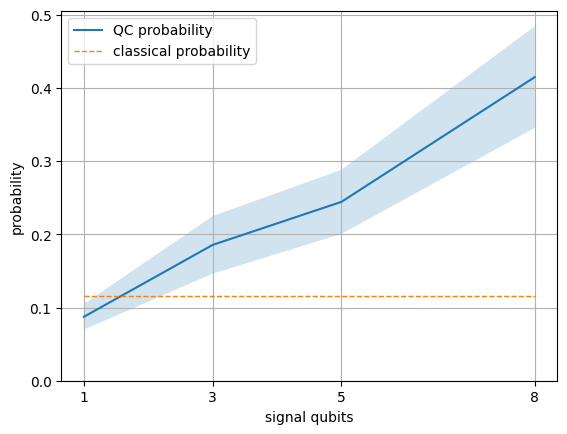

Violations per signal qubit count:


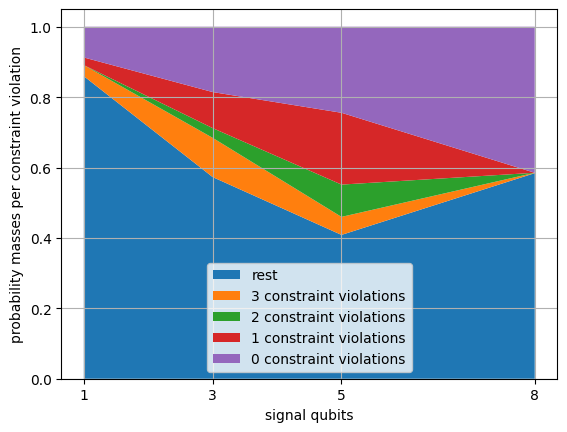

<Figure size 640x480 with 0 Axes>

In [29]:
node_counts = get_node_counts(graph_coloring_experiments)

for node_count in node_counts:

    per_node_experiments = filter_experiments(
        graph_coloring_experiments, params={
            "node_count": node_count
        }
    )

    edge_counts = get_edge_counts(per_node_experiments)

    for edge_count in edge_counts:
        rel_graph_coloring_experiments = filter_experiments(
            per_node_experiments, params={
                "node_count": node_count,
                "edge_count": edge_count
            }
        )

        printb(
            f"\nGraph results with {node_count} nodes and {edge_count} edges\n")

        print("Probability of measuring a correct solution over signal qubit count:")
        classical_probability = 1 / \
            compute_graph_coloring_search_space_sizes(
                rel_graph_coloring_experiments)[0]
        plot_probability_per_signal_qubit_count(
            rel_graph_coloring_experiments, target_path=f"figures/graph_coloring_{node_count}n_{edge_count}e_probabilities.png",
            classical_probability=classical_probability
        )

        print("Violations per signal qubit count:")
        plot_violations_per_signal_qubit_count(rel_graph_coloring_experiments)

### Circuit Depth per Signal Qubit Count


Graph results with 4 nodes and 3 edges

Oracle depth over signal qubit count:
Oracle depths: [60.233333333333334, 42.4, 36.766666666666666, 34.666666666666664]
Signal qubit counts: [1, 3, 5, 7]


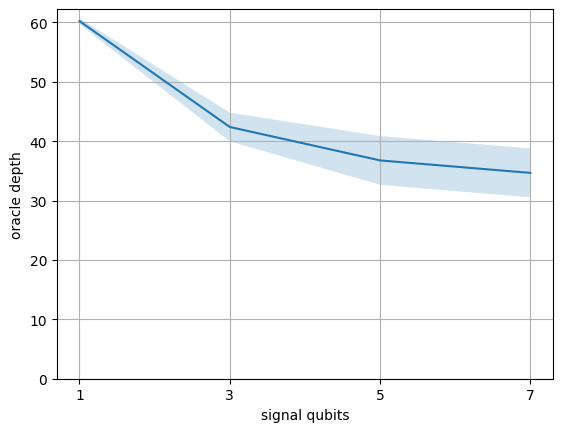

Oracle gates over signal qubit count:
Gate counts: [123, 119, 118, 117]
Signal qubit counts: [1, 3, 5, 7]


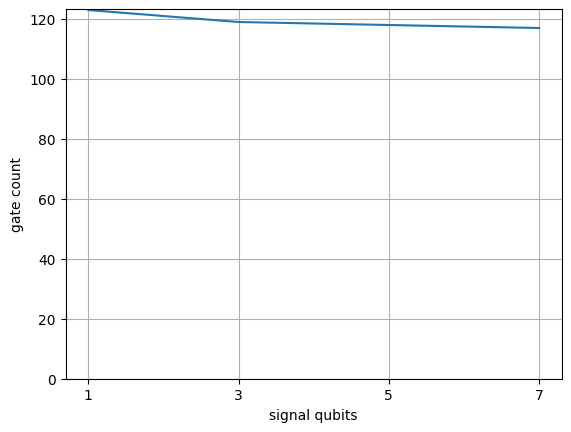


Graph results with 4 nodes and 5 edges

Oracle depth over signal qubit count:
Oracle depths: [78.8, 57.96666666666667, 52.86666666666667, 50.733333333333334]
Signal qubit counts: [1, 3, 5, 9]


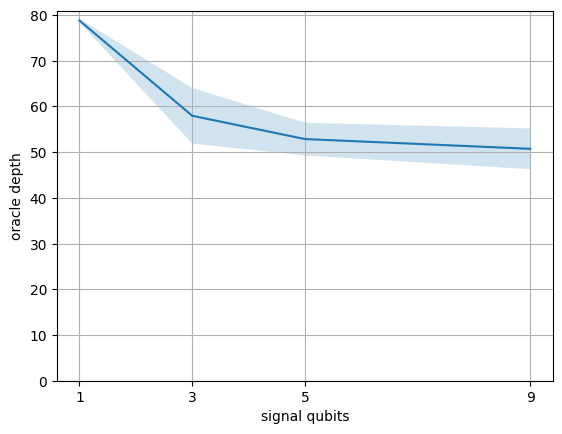

Oracle gates over signal qubit count:
Gate counts: [165, 159, 158, 157]
Signal qubit counts: [1, 3, 5, 9]


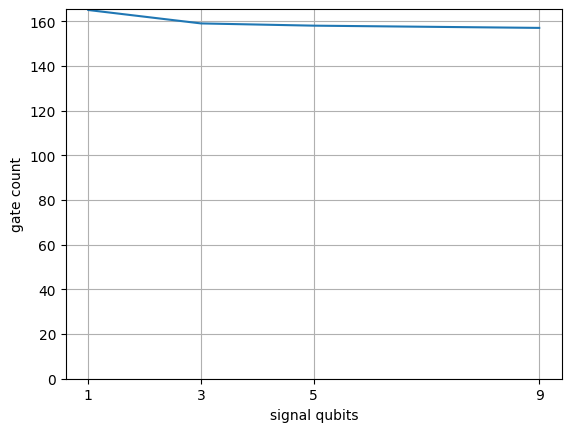


Graph results with 5 nodes and 8 edges

Oracle depth over signal qubit count:
Oracle depths: [71.7, 60.03333333333333, 58.46666666666667, 55.06666666666667]
Signal qubit counts: [1, 3, 5, 8]


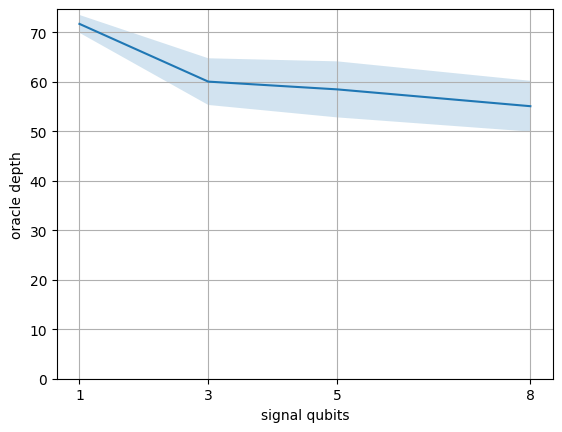

Oracle gates over signal qubit count:
Gate counts: [178, 173, 172, 171]
Signal qubit counts: [1, 3, 5, 8]


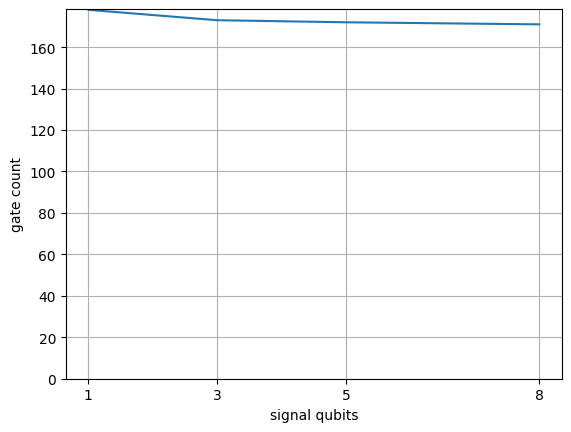

<Figure size 640x480 with 0 Axes>

In [30]:
node_counts = get_node_counts(graph_coloring_experiments)

for node_count in node_counts:

    per_node_experiments = filter_experiments(
        graph_coloring_experiments, params={
            "node_count": node_count
        }
    )

    edge_counts = get_edge_counts(per_node_experiments)

    for edge_count in edge_counts:
        rel_graph_coloring_experiments = filter_experiments(
            per_node_experiments, params={
                "node_count": node_count,
                "edge_count": edge_count
            }
        )

        printb(
            f"\nGraph results with {node_count} nodes and {edge_count} edges\n")

        print("Oracle depth over signal qubit count:")
        plot_oracle_depth_per_signal_qubit_count(
            rel_graph_coloring_experiments, target_path=f"figures/graph_coloring_{node_count}n_{edge_count}e_circuit_depths.png"
        )
        
        print("Oracle gates over signal qubit count:")
        plot_oracle_gates_per_signal_qubit_count(
            rel_graph_coloring_experiments
        )